# Sequence Models → Attention → Tiny Transformer

Progression:
1) RNN
2) GRU
3) Scaled dot-product attention
4) Tiny Transformer LM (masked self-attention)
5) Visualize attention
6) Remove positional embeddings experiment



## Setup

In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Reproducibility

In [2]:
def seed_everything(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)


## Toy task: sequence copy (next-token prediction)

Generate sequences of tokens. Input is `x[:T-1]`, target is `x[1:]`.


In [3]:
def generate_batch(batch_size: int, T: int, vocab: int, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.integers(0, vocab, size=(batch_size, T), dtype=np.int64)
    inp = x[:, :-1]
    tgt = x[:, 1:]
    return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

inp, tgt = generate_batch(2, T=8, vocab=10, seed=0)
print("inp:\n", inp)
print("tgt:\n", tgt)


inp:
 tensor([[8, 6, 5, 2, 3, 0, 0],
        [1, 8, 6, 9, 5, 6, 9]])
tgt:
 tensor([[6, 5, 2, 3, 0, 0, 0],
        [8, 6, 9, 5, 6, 9, 7]])


## Config + training utils

In [4]:
@dataclass
class Config:
    vocab: int = 20
    T: int = 32
    batch_size: int = 128
    emb: int = 64
    hidden: int = 128
    lr: float = 2e-3
    epochs: int = 8
    steps_per_epoch: int = 200
    n_heads: int = 4
    ff: int = 128

cfg = Config()

def run_steps(model, optimizer, loss_fn, vocab, T, batch_size, steps):
    model.train()
    losses = []
    for _ in range(steps):
        inp, tgt = generate_batch(batch_size, T, vocab)
        inp = inp.to(device); tgt = tgt.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inp)  # (B, T-1, vocab)
        loss = loss_fn(logits.reshape(-1, vocab), tgt.reshape(-1))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def eval_steps(model, loss_fn, vocab, T, batch_size, steps):
    model.eval()
    losses, accs = [], []
    for _ in range(steps):
        inp, tgt = generate_batch(batch_size, T, vocab)
        inp = inp.to(device); tgt = tgt.to(device)
        logits = model(inp)
        loss = loss_fn(logits.reshape(-1, vocab), tgt.reshape(-1))
        losses.append(loss.item())
        preds = logits.argmax(dim=-1)
        accs.append((preds == tgt).float().mean().item())
    return float(np.mean(losses)), float(np.mean(accs))


## Model A — Simple RNN (manual cell)

In [5]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab: int, emb: int, hidden: int):
        super().__init__()
        self.vocab = vocab
        self.emb = nn.Embedding(vocab, emb)
        self.Wx = nn.Linear(emb, hidden, bias=True)
        self.Wh = nn.Linear(hidden, hidden, bias=False)
        self.proj = nn.Linear(hidden, vocab)

    def forward(self, inp):
        B, T = inp.shape
        x = self.emb(inp)  # (B,T,emb)
        h = torch.zeros(B, self.Wh.in_features, device=inp.device)
        outs = []
        for t in range(T):
            h = torch.tanh(self.Wx(x[:, t]) + self.Wh(h))
            outs.append(self.proj(h))
        return torch.stack(outs, dim=1)  # (B,T,vocab)

rnn = SimpleRNN(cfg.vocab, cfg.emb, cfg.hidden).to(device)
opt = optim.AdamW(rnn.parameters(), lr=cfg.lr)
loss_fn = nn.CrossEntropyLoss()

hist_rnn = {"va_acc": [], "va_loss": []}
for ep in range(1, cfg.epochs+1):
    tr_loss = run_steps(rnn, opt, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, cfg.steps_per_epoch)
    va_loss, va_acc = eval_steps(rnn, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, steps=50)
    hist_rnn["va_loss"].append(va_loss); hist_rnn["va_acc"].append(va_acc)
    print(f"RNN ep={ep:02d} tr_loss={tr_loss:.3f} va_loss={va_loss:.3f} va_acc={va_acc:.3f}")


RNN ep=01 tr_loss=3.002 va_loss=2.999 va_acc=0.051
RNN ep=02 tr_loss=2.999 va_loss=2.998 va_acc=0.049
RNN ep=03 tr_loss=2.997 va_loss=2.997 va_acc=0.051
RNN ep=04 tr_loss=2.997 va_loss=2.996 va_acc=0.050
RNN ep=05 tr_loss=2.996 va_loss=2.996 va_acc=0.050
RNN ep=06 tr_loss=2.996 va_loss=2.996 va_acc=0.049
RNN ep=07 tr_loss=2.996 va_loss=2.996 va_acc=0.050
RNN ep=08 tr_loss=2.996 va_loss=2.996 va_acc=0.051


## Model B — GRU

In [6]:
class GRUModel(nn.Module):
    def __init__(self, vocab: int, emb: int, hidden: int):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb)
        self.gru = nn.GRU(input_size=emb, hidden_size=hidden, batch_first=True)
        self.proj = nn.Linear(hidden, vocab)
    def forward(self, inp):
        x = self.emb(inp)
        h, _ = self.gru(x)
        return self.proj(h)

gru = GRUModel(cfg.vocab, cfg.emb, cfg.hidden).to(device)
opt = optim.AdamW(gru.parameters(), lr=cfg.lr)
loss_fn = nn.CrossEntropyLoss()

hist_gru = {"va_acc": [], "va_loss": []}
for ep in range(1, cfg.epochs+1):
    tr_loss = run_steps(gru, opt, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, cfg.steps_per_epoch)
    va_loss, va_acc = eval_steps(gru, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, steps=50)
    hist_gru["va_loss"].append(va_loss); hist_gru["va_acc"].append(va_acc)
    print(f"GRU ep={ep:02d} tr_loss={tr_loss:.3f} va_loss={va_loss:.3f} va_acc={va_acc:.3f}")


GRU ep=01 tr_loss=2.998 va_loss=2.997 va_acc=0.049
GRU ep=02 tr_loss=2.997 va_loss=2.996 va_acc=0.050
GRU ep=03 tr_loss=2.996 va_loss=2.996 va_acc=0.050
GRU ep=04 tr_loss=2.996 va_loss=2.996 va_acc=0.050
GRU ep=05 tr_loss=2.996 va_loss=2.996 va_acc=0.050
GRU ep=06 tr_loss=2.996 va_loss=2.996 va_acc=0.051
GRU ep=07 tr_loss=2.996 va_loss=2.996 va_acc=0.049
GRU ep=08 tr_loss=2.996 va_loss=2.996 va_acc=0.050


## Attention — scaled dot-product + causal mask

In [7]:
def causal_mask(T: int, device):
    return torch.tril(torch.ones(T, T, device=device))

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3*d_model, bias=False)
        self.out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, return_weights=False):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1,2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1,2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1,2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B,nH,T,T)
        mask = causal_mask(T, x.device)
        scores = scores.masked_fill(mask == 0, float("-inf"))
        w = F.softmax(scores, dim=-1)
        out = w @ v  # (B,nH,T,dH)
        out = out.transpose(1,2).contiguous().view(B, T, C)
        out = self.out(out)
        if return_weights:
            return out, w
        return out


## Tiny Transformer LM (masked self-attention)

Token embedding + positional embedding + 2 blocks.


In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x, return_attn=False):
        if return_attn:
            a, w = self.attn(self.ln1(x), return_weights=True)
            x = x + a
            x = x + self.ff(self.ln2(x))
            return x, w
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class TinyTransformerLM(nn.Module):
    def __init__(self, vocab: int, T: int, d_model: int, n_heads: int, d_ff: int, n_layers: int = 2):
        super().__init__()
        self.vocab = vocab
        self.T = T
        self.tok = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(T, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab, bias=False)

    def forward(self, inp, return_attn=False):
        B, T = inp.shape
        assert T <= self.T
        pos = torch.arange(T, device=inp.device)
        x = self.tok(inp) + self.pos(pos)[None, :, :]

        attn = None
        for i, blk in enumerate(self.blocks):
            if return_attn and i == len(self.blocks)-1:
                x, attn = blk(x, return_attn=True)
            else:
                x = blk(x)

        x = self.ln(x)
        logits = self.head(x)
        if return_attn:
            return logits, attn
        return logits

tt = TinyTransformerLM(cfg.vocab, T=cfg.T-1, d_model=cfg.emb, n_heads=cfg.n_heads, d_ff=cfg.ff, n_layers=2).to(device)
opt = optim.AdamW(tt.parameters(), lr=cfg.lr)
loss_fn = nn.CrossEntropyLoss()

hist_tt = {"va_acc": [], "va_loss": []}
for ep in range(1, cfg.epochs+1):
    tr_loss = run_steps(tt, opt, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, cfg.steps_per_epoch)
    va_loss, va_acc = eval_steps(tt, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, steps=50)
    hist_tt["va_loss"].append(va_loss); hist_tt["va_acc"].append(va_acc)
    print(f"TT  ep={ep:02d} tr_loss={tr_loss:.3f} va_loss={va_loss:.3f} va_acc={va_acc:.3f}")


TT  ep=01 tr_loss=3.004 va_loss=2.999 va_acc=0.051
TT  ep=02 tr_loss=2.997 va_loss=2.997 va_acc=0.049
TT  ep=03 tr_loss=2.997 va_loss=2.997 va_acc=0.049
TT  ep=04 tr_loss=2.997 va_loss=2.996 va_acc=0.050
TT  ep=05 tr_loss=2.997 va_loss=2.997 va_acc=0.050
TT  ep=06 tr_loss=2.997 va_loss=2.997 va_acc=0.050
TT  ep=07 tr_loss=2.997 va_loss=2.997 va_acc=0.050
TT  ep=08 tr_loss=2.996 va_loss=2.997 va_acc=0.050


## Compare RNN vs GRU vs Transformer

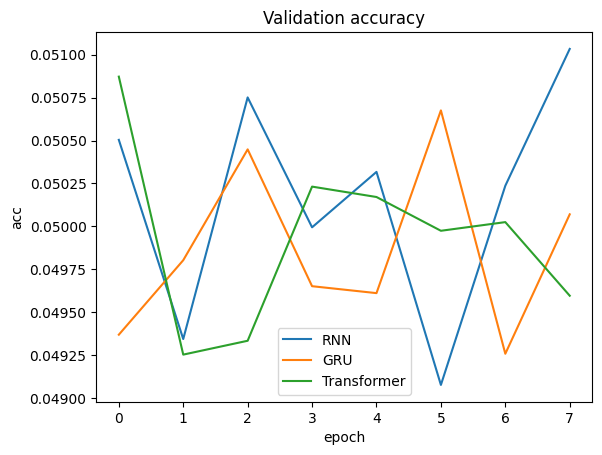

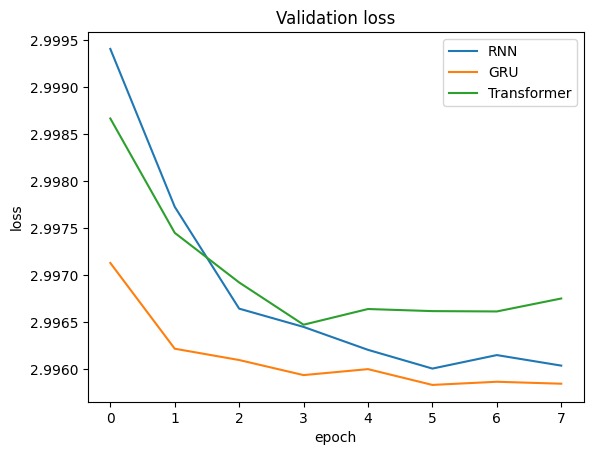

In [9]:
plt.figure()
plt.plot(hist_rnn["va_acc"], label="RNN")
plt.plot(hist_gru["va_acc"], label="GRU")
plt.plot(hist_tt["va_acc"], label="Transformer")
plt.title("Validation accuracy")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()

plt.figure()
plt.plot(hist_rnn["va_loss"], label="RNN")
plt.plot(hist_gru["va_loss"], label="GRU")
plt.plot(hist_tt["va_loss"], label="Transformer")
plt.title("Validation loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()


## Visualize attention matrix (one head)

Causal attention shows lower-triangular structure.


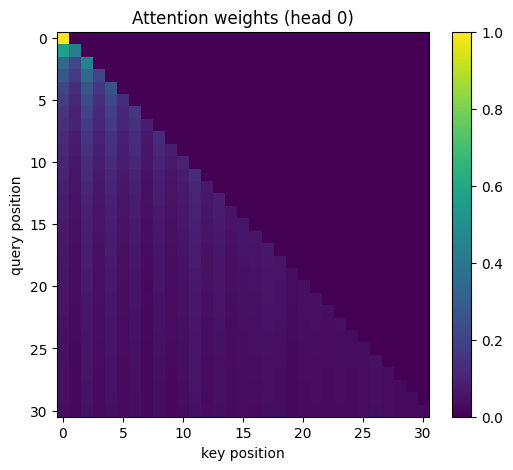

tokens: [ 0 13 11  1 18  4  5  3  6  3  6 16  9 18  8  5 15 16 17 17  0 10  5  4
  4 16 15  4  8 14  2]


In [10]:
inp, tgt = generate_batch(batch_size=1, T=cfg.T, vocab=cfg.vocab, seed=123)
inp = inp.to(device)

tt.eval()
with torch.no_grad():
    logits, attn = tt(inp, return_attn=True)  # attn: (B,nH,T,T)

attn0 = attn[0, 0].cpu().numpy()  # head 0
tokens = inp[0].cpu().numpy()

plt.figure(figsize=(6,5))
plt.imshow(attn0, aspect="auto")
plt.title("Attention weights (head 0)")
plt.xlabel("key position"); plt.ylabel("query position")
plt.colorbar(); plt.show()

print("tokens:", tokens)


## Remove positional embeddings experiment

Order should matter → removing pos embeddings typically hurts.


NoPos ep=01 va_acc=0.050
NoPos ep=02 va_acc=0.050
NoPos ep=03 va_acc=0.050
NoPos ep=04 va_acc=0.050
NoPos ep=05 va_acc=0.050
NoPos ep=06 va_acc=0.050
NoPos ep=07 va_acc=0.051
NoPos ep=08 va_acc=0.050


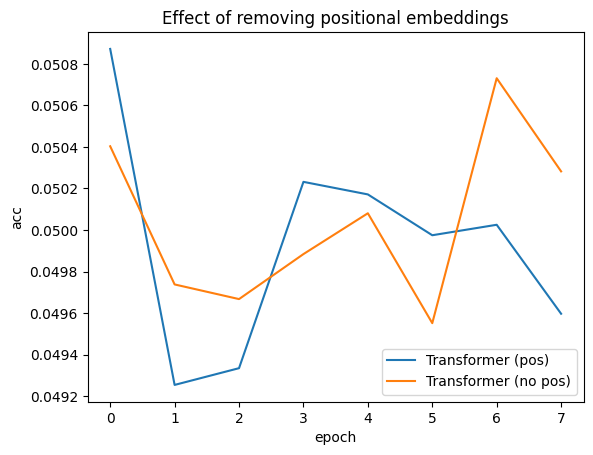

In [11]:
class TinyTransformerNoPos(TinyTransformerLM):
    def forward(self, inp, return_attn=False):
        B, T = inp.shape
        x = self.tok(inp)  # no pos
        attn = None
        for i, blk in enumerate(self.blocks):
            if return_attn and i == len(self.blocks)-1:
                x, attn = blk(x, return_attn=True)
            else:
                x = blk(x)
        x = self.ln(x)
        logits = self.head(x)
        if return_attn:
            return logits, attn
        return logits

tt_nopos = TinyTransformerNoPos(cfg.vocab, T=cfg.T-1, d_model=cfg.emb, n_heads=cfg.n_heads, d_ff=cfg.ff, n_layers=2).to(device)
opt = optim.AdamW(tt_nopos.parameters(), lr=cfg.lr)
loss_fn = nn.CrossEntropyLoss()

hist_nopos = {"va_acc": []}
for ep in range(1, cfg.epochs+1):
    _ = run_steps(tt_nopos, opt, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, cfg.steps_per_epoch)
    _, va_acc = eval_steps(tt_nopos, loss_fn, cfg.vocab, cfg.T, cfg.batch_size, steps=50)
    hist_nopos["va_acc"].append(va_acc)
    print(f"NoPos ep={ep:02d} va_acc={va_acc:.3f}")

plt.figure()
plt.plot(hist_tt["va_acc"], label="Transformer (pos)")
plt.plot(hist_nopos["va_acc"], label="Transformer (no pos)")
plt.title("Effect of removing positional embeddings")
plt.xlabel("epoch"); plt.ylabel("acc")
plt.legend(); plt.show()
